In [3]:
library(SoupX)

In [4]:
library(SingleCellExperiment)
library(data.table)
library(Matrix)
library(EmptyDropsMultiome)
library(ggplot2)
library(dplyr)
library(Seurat)
library(scuttle)

Warning message:
“package ‘SingleCellExperiment’ was built under R version 4.4.2”
Loading required package: SummarizedExperiment

Warning message:
“package ‘SummarizedExperiment’ was built under R version 4.4.2”
Loading required package: MatrixGenerics

Warning message:
“package ‘MatrixGenerics’ was built under R version 4.4.2”
Loading required package: matrixStats

Warning message:
“package ‘matrixStats’ was built under R version 4.4.2”

Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
  

In [5]:
io = list()
io$home = '/rds/project/rds-SDzz0CATGms/users/bt392/'

io$datadir = sprintf('%s/09_Eomes_invitro_blood/original/', io$home)

In [6]:
sample = '2_Eo_DEG_G9_day4_VC'

In [7]:
unfiltered = sprintf('%s/%s/outs/unfiltered_feature_bc_matrix/', io$datadir, sample)
barcodes = fread(sprintf('%s/barcodes.tsv.gz', unfiltered), header = F)
features = fread(sprintf('%s/features.tsv.gz', unfiltered))
matrix = readMM(gzfile((sprintf('%s/matrix.mtx.gz', unfiltered))))

In [8]:
    rownames(matrix) = features$V2
    colnames(matrix) = barcodes$V1

In [9]:
unfiltered_matrix = matrix

In [10]:
filtered = sprintf('%s/multiome_reanalysis/results/data/%s/', io$home, sample)
barcodes = fread(sprintf('%s/barcodes.tsv', filtered), header = F)
features = fread(sprintf('%s/features.tsv', filtered))
matrix = readMM(gzfile((sprintf('%s/matrix.mtx', filtered))))

In [11]:
    rownames(matrix) = features$V2
    colnames(matrix) = barcodes$V1

In [12]:
filtered_matrix = matrix

In [13]:
genes = features[V3 == 'Gene Expression', V2]
unfiltered_matrix = unfiltered_matrix[genes, ]
filtered_matrix = filtered_matrix[genes, ]

In [14]:
dim(unfiltered_matrix)
dim(filtered_matrix)

[1]  32285 736279

[1] 32285  3975

In [15]:
rownames(unfiltered_matrix) <- make.unique(rownames(unfiltered_matrix))
rownames(filtered_matrix) <- make.unique(rownames(filtered_matrix))

### Quick clustering using seurat

In [16]:
pbmc <- CreateSeuratObject(counts = filtered_matrix, project = "pbmc3k", min.cells = 0, min.features = 0)

Warning message:
“Data is of class dgTMatrix. Coercing to dgCMatrix.”


In [43]:
pbmc <- NormalizeData(pbmc, normalization.method = "LogNormalize", scale.factor = 10000)
pbmc <- FindVariableFeatures(pbmc, selection.method = "vst", nfeatures = 4000)
all.genes <- rownames(pbmc)
pbmc <- ScaleData(pbmc, features = all.genes)
pbmc <- RunPCA(pbmc, features = VariableFeatures(object = pbmc))
pbmc <- FindNeighbors(pbmc, dims = 1:10)
pbmc <- FindClusters(pbmc, resolution = 0.7)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  Pard3, Tcf12, Magi1, Gpc6, Ptprg, Dlg1, Sptbn1, Tnks, Large1, Srgap2 
	   Diaph2, Acaca, Zfp407, Prrc2c, Scd2, Qk, Prtg, Magi3, Nipbl, Elovl6 
	   Msi2, Gnaq, Bmpr2, Herc1, Exoc4, Rbms1, Lpp, Ranbp2, Pbx3, Pola1 
Negative:  Tmsb4x, Crabp1, Mesp1, mt-Co1, Serbp1, Cdk4, Rbp1, Sod1, Chchd10, Mt2 
	   Dnd1, Ifitm3, Dusp9, Rhox5, Fgf8, Ptgds, Cldn7, Krt8, Tagln, Prdm14 
	   Cfc1, Sprr2a3, Lrp1b, Alox15, Hoxb1, Apela, Tdrkh, Acta2, Anxa2, Pbk 
PC_ 2 
Positive:  Tek, Vav3, Csgalnact1, Hapln1, Rapgef5, Kdr, F2r, Egfl7, Mast4, Bmp6 
	   Edil3, Myo10, Gpm6b, Rhoj, Ramp2, Tal1, Arhgap31, Arap3, Iqgap2, Flt1 
	   Zfpm2, Galnt18, Cdh5, Scube2, Fbn1, Dysf, Gadd45g, Slc22a23, Zfp711, Cbfa2t3 
Negative:  Gpc3, Bach2, Slc38a4, Ptk7, Unc5c, Tgfb2, Tenm3, Kif26b, Igsf3, Tbx20 
	   Prtg, Zfp516, Wnt5a, Hmga2, Zbtb20, Slit3, Cdh11, Platr25, Lhfpl2, Peg3 
	   Pcmtd1, Crispld1, Sall4, K

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 3975
Number of edges: 128836

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8044
Number of communities: 9
Elapsed time: 0 seconds


In [44]:
sc = SoupChannel(unfiltered_matrix, filtered_matrix)

In [52]:
pbmc <- FindClusters(pbmc, resolution = 1)
sc = setClusters(sc, pbmc$seurat_clusters)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 3975
Number of edges: 128836

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7750
Number of communities: 14
Elapsed time: 0 seconds


147 genes passed tf-idf cut-off and 83 soup quantile filter.  Taking the top 83.

Using 380 independent estimates of rho.

Estimated global rho of 0.24



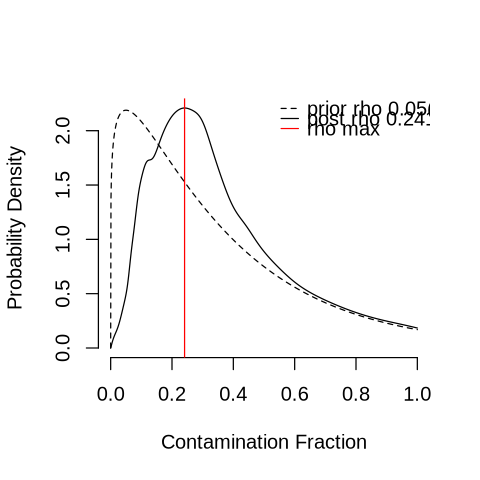

In [56]:
sc = autoEstCont(sc, tfidfMin = 0.9, soupQuantile = 0.7)

In [57]:
out = adjustCounts(sc)

Warning message in sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w], :
“'giveCsparse' is deprecated; setting repr="T" for you”
Expanding counts from 14 clusters to 3975 cells.



In [58]:
filtered_matrix[1:10, 1:10]

out[1:10, 1:10]

  [[ suppressing 10 column names ‘AAACAGCCAATTAACC-1’, ‘AAACAGCCACATAGCC-1’, ‘AAACAGCCATAAGGAC-1’ ... ]]



10 x 10 sparse Matrix of class "dgTMatrix"
                           
Xkr4    . . 8 . . . . . . .
Gm1992  . . . . . . . . . .
Gm19938 . . . . . . . . . .
Gm37381 . . . . . . . . . .
Rp1     . . . . . . . . . .
Sox17   1 . . . . . . . . .
Gm37587 . . . . . . . . . .
Gm37323 . . . . . . . . . .
Mrpl15  4 1 4 2 1 1 1 4 2 .
Lypla1  3 1 3 2 3 1 2 3 . .

  [[ suppressing 10 column names ‘AAACAGCCAATTAACC-1’, ‘AAACAGCCACATAGCC-1’, ‘AAACAGCCATAAGGAC-1’ ... ]]



10 x 10 sparse Matrix of class "dgCMatrix"
                                                                           
Xkr4    .         .         7.9028148 .         .        .         .       
Gm1992  .         .         .         .         .        .         .       
Gm19938 .         .         .         .         .        .         .       
Gm37381 .         .         .         .         .        .         .       
Rp1     .         .         .         .         .        .         .       
Sox17   0.7526747 .         .         .         .        .         .       
Gm37587 .         .         .         .         .        .         .       
Gm37323 .         .         .         .         .        .         .       
Mrpl15  2.3916870 0.0000000 0.6205885 0.2446913 0.000000 0.0000000 0.000000
Lypla1  2.7516661 0.7814588 2.4781972 1.7060089 2.822433 0.6249047 1.813631
                           
Xkr4    .        .        .
Gm1992  .        .        .
Gm19938 .        .        .
Gm37381 .

In [60]:
pbmc <- RunUMAP(pbmc, dims = 1:10)

13:01:11 UMAP embedding parameters a = 0.9922 b = 1.112

13:01:11 Read 3975 rows and found 10 numeric columns

13:01:11 Using Annoy for neighbor search, n_neighbors = 30

13:01:11 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

13:01:11 Writing NN index file to temp file /tmp/RtmpamNEDQ/file25e9655f8832a

13:01:11 Searching Annoy index using 1 thread, search_k = 3000

13:01:13 Annoy recall = 100%

13:01:13 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

13:01:15 Initializing from normalized Laplacian + noise (using RSpectra)

13:01:15 Commencing optimization for 500 epochs, with 158652 positive edges

13:01:15 Using rng type: pcg

13:01:20 Optimization finished



In [61]:
umap = as.data.table(pbmc@reductions$umap@cell.embeddings, keep.rownames = T)

In [62]:
sce_original = SingleCellExperiment(list(counts = filtered_matrix))

In [63]:
sce_original = logNormCounts(sce_original)

In [64]:
sce_soupx = SingleCellExperiment(list(counts = out))

In [65]:
sce_soupx = logNormCounts(sce_soupx)

In [77]:
ratio = filtered_matrix / out

In [89]:
ratio[is.infinite(ratio)] <- 2

In [98]:
test = rowMeans(ratio, na.rm = T)

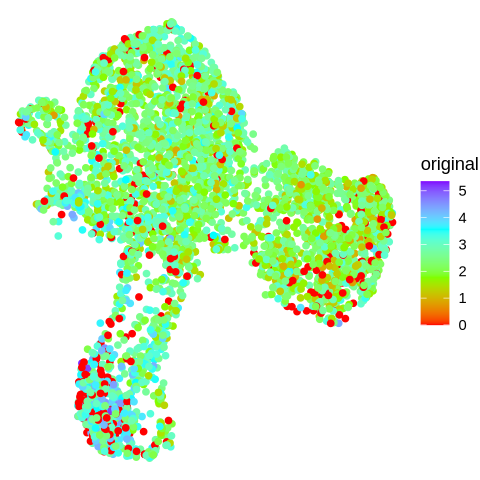

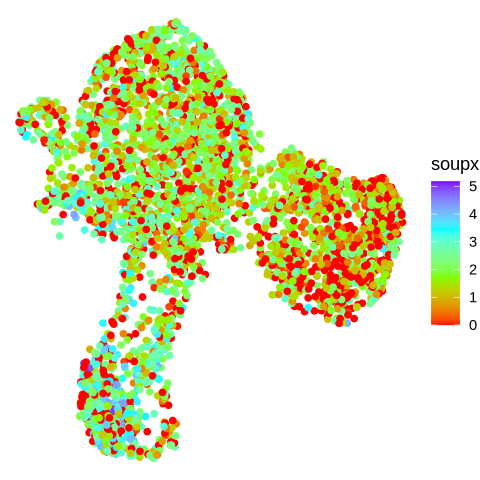

In [100]:
gene = 'Tceal9'
umap = umap[match(colnames(sce_original), rn)]
umap$original = as.numeric(logcounts(sce_original[gene,]))
umap$soupx = as.numeric(logcounts(sce_soupx[gene,]))


options(repr.plot.height = 4, repr.plot.width = 4)
p1 = ggplot(umap, aes(umap_1, umap_2)) + 
    geom_point(aes(color=original)) + 
    scale_color_gradientn(colors = rainbow(4)) + 
    theme_void()

p2 = ggplot(umap, aes(umap_1, umap_2)) + 
    geom_point(aes(color=soupx)) + 
    scale_color_gradientn(colors = rainbow(4)) + 
    theme_void()

p1
p2

In [101]:
pbmc <- CreateSeuratObject(counts = out, project = "pbmc3k", min.cells = 0, min.features = 0)
pbmc <- NormalizeData(pbmc, normalization.method = "LogNormalize", scale.factor = 10000)
pbmc <- FindVariableFeatures(pbmc, selection.method = "vst", nfeatures = 4000)
all.genes <- rownames(pbmc)
pbmc <- ScaleData(pbmc, features = all.genes)
pbmc <- RunPCA(pbmc, features = VariableFeatures(object = pbmc))
pbmc <- RunUMAP(pbmc, dims = 1:10, verbose = F)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  Rps15a, Rpl37a, Rpl32, Gm10076, Rpl19, Rps15, Rps26, Rpl36, Ppia, Rpl7 
	   Rps21, Rpl26, Rps24, Rps12, Rps17, Rps13, Rpl23a, Rpl14, Rps11, Rpl37 
	   Rpl27, Rpl34, Rpl17, Mif, Rpl35a, Rps27l, Ndufa4, H2afz, Rpl8, Rps7 
Negative:  Gpc6, Sptbn1, Qk, Magi3, Ranbp2, Tbc1d5, Gls, Rbms1, Mdn1, Zdbf2 
	   Aff3, Mast4, Mib1, Fmnl2, Man2a1, Nrp2, Fchsd2, Pkp4, Tmem164, Pbrm1 
	   Col4a1, St6galnac3, Zeb2, Chd4, Kcnq1ot1, Etv6, Gtdc1, Yes1, Afdn, Eif4g1 
PC_ 2 
Positive:  Gpc3, Slc38a4, Ptk7, Bach2, Tgfb2, Unc5c, Kif26b, Igsf3, Tbx20, Wnt5a 
	   Cdh11, Slit3, Hmga2, Peg10, Lhfpl2, Crispld1, Zbtb20, Peg3, Dlk1, Mllt3 
	   Prickle1, Klhl32, Rps6ka6, Msx1, Pid1, Limch1, Tenm4, Sdc2, Efna5, Cntn4 
Negative:  Fli1, Tek, Ramp2, Hapln1, F2r, Gadd45g, Csgalnact1, Kdr, Rapgef5, Myzap 
	   Reln, Bmp6, Mast4, Arap3, Edil3, Tal1, Rasip1, Myo10, Gpm6b, Rhoj 
	   Iqgap2, Fbn1, Tgfbr3, A

In [102]:
umap = as.data.table(pbmc@reductions$umap@cell.embeddings, keep.rownames = T)

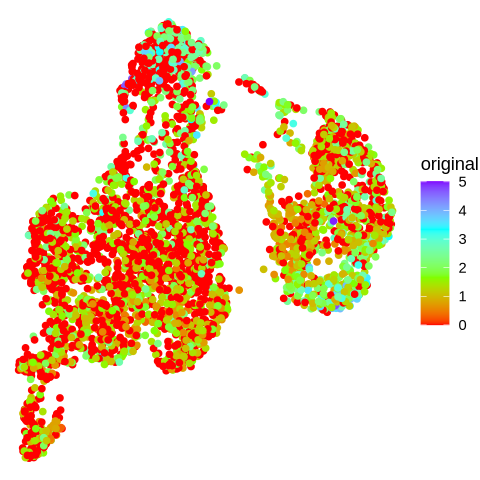

In [110]:
gene = 'Etv2'
umap = umap[match(colnames(sce_original), rn)]
umap$original = as.numeric(logcounts(sce_original[gene,]))
ggplot(umap, aes(umap_1, umap_2)) + 
    geom_point(aes(color=original)) + 
    scale_color_gradientn(colors = rainbow(4)) + 
    theme_void()

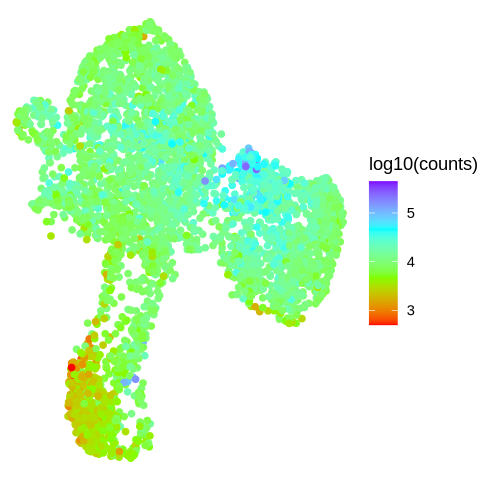

In [68]:
umap = umap[match(colnames(sce_original), rn)]
umap$counts = as.numeric(colSums(counts(sce_original)))

options(repr.plot.height = 4, repr.plot.width = 4)
ggplot(umap, aes(umap_1, umap_2)) + 
    geom_point(aes(color= log10(counts))) + 
    scale_color_gradientn(colors = rainbow(4)) + 
    theme_void()

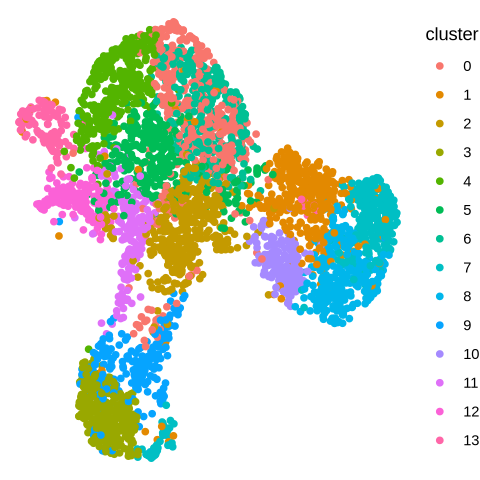

In [97]:
umap = umap[match(colnames(sce_original), rn)]
umap$cluster = pbmc$seurat_clusters

options(repr.plot.height = 4, repr.plot.width = 4)
ggplot(umap, aes(umap_1, umap_2)) + 
    geom_point(aes(color= cluster)) + 
    theme_void()

In [82]:
cell_counts = data.table(
        sums = colSums(unfiltered_matrix),
        cell = colnames(unfiltered_matrix)
                        ) %>%
    .[order(-sums)] %>% 
    .[, idx := .I]

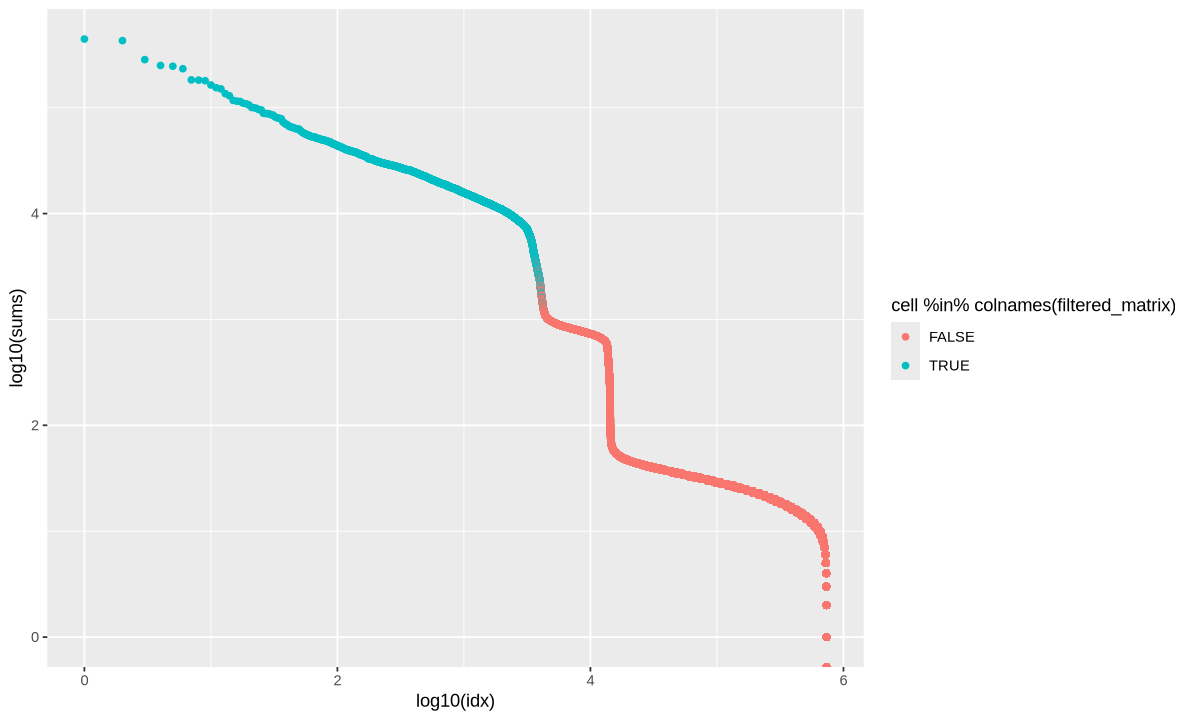

In [87]:
options(repr.plot.height = 6, repr.plot.width = 10)

ggplot(cell_counts, aes(log10(idx), log10(sums), color = cell %in% colnames(filtered_matrix))) + 
    geom_point()

In [93]:
cellranger_cells = fread(paste0(io$datadir, '2_Eo_DEG_G9_day4_VC/outs/filtered_feature_bc_matrix/barcodes.tsv.gz'), header = F)

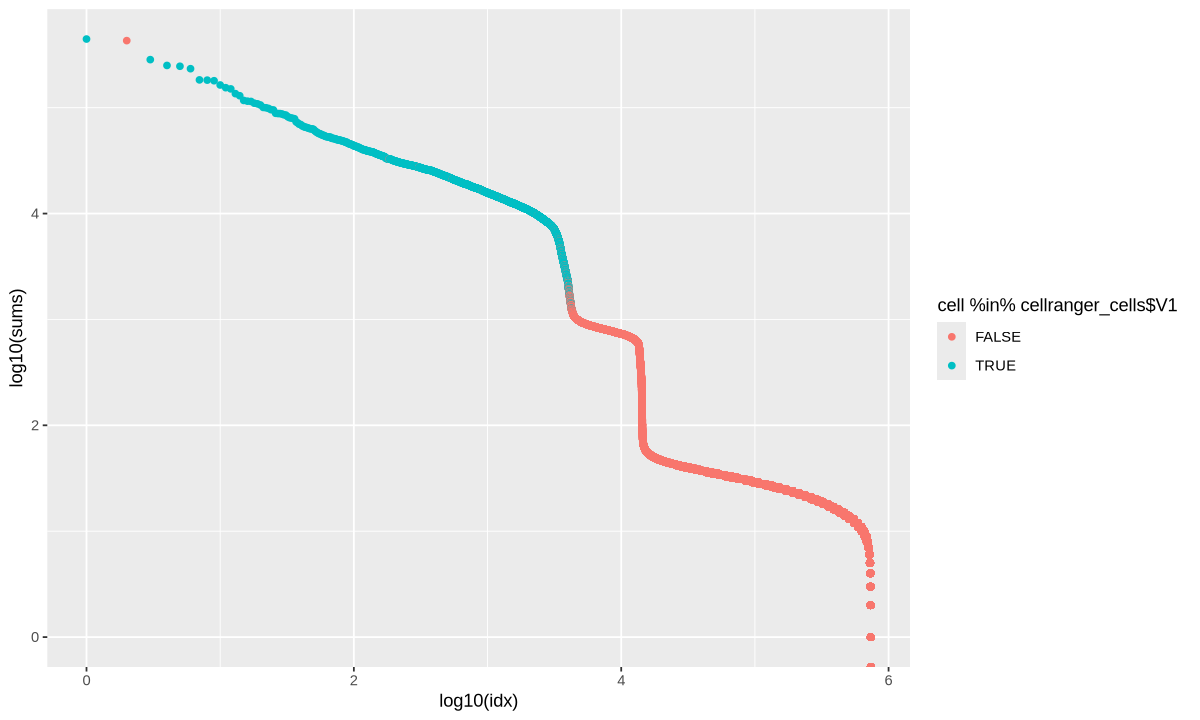

In [95]:
options(repr.plot.height = 6, repr.plot.width = 10)

ggplot(cell_counts, aes(log10(idx), log10(sums), color = cell %in% cellranger_cells$V1)) + 
    geom_point()

In [99]:
summary(cellranger_cells$V1 %in% colnames(filtered_matrix))
summary(colnames(filtered_matrix) %in% cellranger_cells$V1)

   Mode   FALSE    TRUE 
logical     111    3920 

   Mode   FALSE    TRUE 
logical      55    3920 